# Principal Q-Learning Training Loop



**Structure:**
1. Agent solves its MDP exactly given the current principal policy and gives Q-bar
2. Principal runs Q-learning episodes using that Q_bar
3. Principal's updated scoreboard defines a new policy and repeats

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from principal_agent_mdp import PrincipalAgentMDP
from agent import Agent
from principal_isa import Principal

In [26]:
# Hyperparameters
GAMMA          = 1.0
ALPHA          = 0.1    # principal learning rate
EPSILON        = 0.1    # principal exploration rate
N_META         = 30     # number of meta-algorithm iterations
N_EPISODES     = 1000    # Q-learning episodes per meta-iteration
T              = 10     # steps per episode
B_GRID_STEP    = 0.1

In [27]:
# Setup
mdp = PrincipalAgentMDP(gamma=GAMMA)

# Principal's reward: r^p(s, L) = 14/9, r^p(s, R) = 0
r_p = np.zeros((mdp.n_states, mdp.n_outcomes))
for s in range(mdp.n_states):
    r_p[s, 0] = 14 / 9
    r_p[s, 1] = 0.0

agent     = Agent(mdp)
principal = Principal(mdp, r_p, alpha=ALPHA, epsilon=EPSILON, b_grid_step=B_GRID_STEP)

# Start with zero contracts, principal offers no contract
rho = {s: np.array([0.0, 0.0]) for s in range(mdp.n_states)}

In [28]:
def compute_Q_bar(agent, rho):
    """
    After agent.solve(rho), compute the truncated Q-function:
        Q_bar[s, a] = Q_agent(s, rho[s], a)

    This is what the principal uses in the LP (Eq. 3) to design contracts.
    It tells the principal: 'given your current contract offer at state s,
    how much does the agent value each action?'
    """
    _, Q_agent, _ = agent.solve(rho)

    Q_bar = np.zeros((mdp.n_states, mdp.n_actions))
    for s in range(mdp.n_states):
        b = rho[s]
        for a in range(mdp.n_actions):
            Q_bar[s, a] = Q_agent(s, b, a)
    return Q_bar

In [29]:
def extract_greedy_rho(principal, agent_Q_bar):
    """
    Extract the principal's current greedy policy as a contract dict.
    For each state: pick the best action from the scoreboard, then LP for contract.
    This is used to tell the agent 'this is what the principal will offer you'.
    """
    rho = {}
    for s in range(mdp.n_states):
        a_p = int(np.argmax(principal.q[s, :]))
        b   = principal.find_best_contract(s, a_p, agent_Q_bar)
        rho[s] = np.array(b)
    return rho

In [ ]:
# Training Loop
history = []   # track principal's q-table over meta-iterations

for meta_it in range(N_META):

    # Reset principal's Q-table so each outer solve is a fresh run for the current agent_Q_bar
    principal.reset()

    # Inner: agent best-responds to current principal policy
    agent_Q_bar = compute_Q_bar(agent, rho)

    #Outer: principal does Q-learning episodes
    for ep in range(N_EPISODES):
        state = mdp.s0

        for t in range(T):
            a_p, b   = principal.induce_action(state, agent_Q_bar)
            o        = mdp.sample_outcome(state, a_p)
            next_state = mdp.T(state, o)

            principal.update(state, a_p, b, o, next_state)
            state = next_state

    # Update rho for next meta-iteration
    rho = extract_greedy_rho(principal, agent_Q_bar)

    history.append(principal.q.copy())
    print(f"Meta-iter {meta_it+1:2d} | q-table:\n{principal.q.round(3)}")
    print(f"           contracts: { {s: rho[s].tolist() for s in rho} }\n")

In [24]:
# Final Results
print("Final Principal Q-table")
print("       induce aL   induce aR")
for s, name in enumerate(["s0", "sL", "sR"]):
    print(f"  {name}:  {principal.q[s, 0]:.3f}      {principal.q[s, 1]:.3f}")

print("\n Final Contracts")
for s, name in enumerate(["s0", "sL", "sR"]):
    a_p = int(np.argmax(principal.q[s, :]))
    b   = rho[s]
    print(f"  {name}: induce {'aL' if a_p==0 else 'aR'}, pay b(L)={b[0]:.1f}, b(R)={b[1]:.1f}")

Final Principal Q-table
       induce aL   induce aR
  s0:  124.875      49.789
  sL:  129.156      113.571
  sR:  125.836      31.694

 Final Contracts
  s0: induce aL, pay b(L)=0.0, b(R)=0.0
  sL: induce aL, pay b(L)=0.0, b(R)=0.0
  sR: induce aL, pay b(L)=0.5, b(R)=0.0


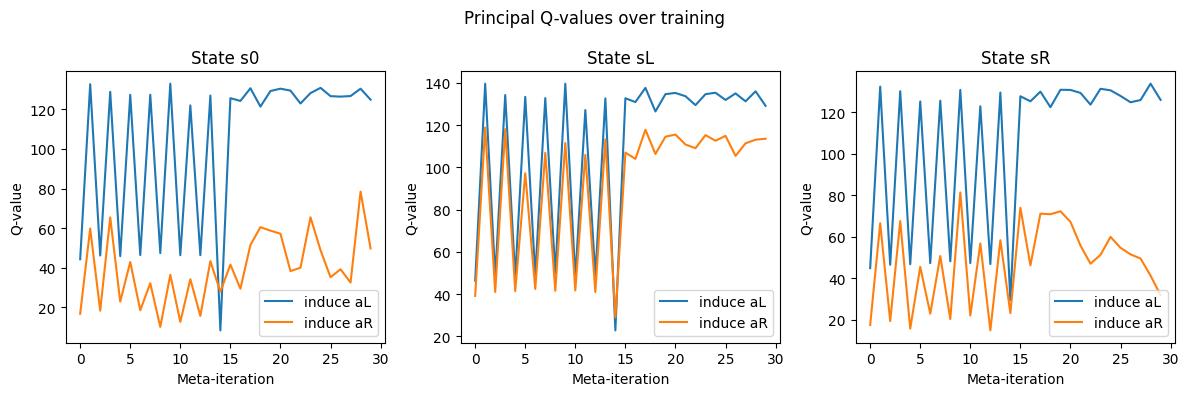

In [25]:
# Plot: Q-values over meta-iterations
history = np.array(history)   # shape: (N_META, n_states, n_actions)

state_names  = ["s0", "sL", "sR"]
action_names = ["induce aL", "induce aR"]

fig, axes = plt.subplots(1, mdp.n_states, figsize=(12, 4), sharey=False)

for s, ax in enumerate(axes):
    for a in range(mdp.n_actions):
        ax.plot(history[:, s, a], label=action_names[a])
    ax.set_title(f"State {state_names[s]}")
    ax.set_xlabel("Meta-iteration")
    ax.set_ylabel("Q-value")
    ax.legend()

plt.suptitle("Principal Q-values over training")
plt.tight_layout()
plt.show()